<a href="https://colab.research.google.com/github/sajjkavinda/ML-based-Intrution-detection-system/blob/main/Final_Results.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Final Results Visualisation

The models compared are:
- Decision Tree
- Random Forest
- XGBoost

Evaluation metrics:
- Accuracy
- Precision
- Recall
- F1-score
- Training Time
- Prediction Time

In [19]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [20]:
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path

Set path for the Dataset and saved models

In [21]:
PROJECT_DIR = Path("/content/drive/MyDrive/MSc_Dissertation")

PROCESSED_DIR = PROJECT_DIR / "Dataset/Processed"

MODEL_DIR = PROJECT_DIR / "Results/Models"

Load saved model results

In [31]:
dt_results = pd.read_csv(
    MODEL_DIR / "decision_tree_results.csv"
)

rf_results = pd.read_csv(
    MODEL_DIR / "random_forest_results.csv"
)

xgb_results = pd.read_csv(
    MODEL_DIR / "xgboost_results.csv"
)

Combine results

In [32]:
model_results = pd.concat(
    [
        dt_results,
        rf_results,
        xgb_results
    ],
    ignore_index=True
)


model_results

,Model,Accuracy,Precision,Recall,F1-score,Training Time (seconds),Prediction Time (seconds)
0,Decision Tree,0.999454,0.997410,0.999856,0.998631,1.804208,0.003913
1,Random Forest,0.999971,0.999928,0.999928,0.999928,19.230237,0.183151
2,XGBoost,0.999986,0.999928,1.000000,0.999964,7.140702,0.140994


Save the combined results

In [33]:
model_results.to_csv(
    PROJECT_DIR / "Results/final_model_comparison.csv",
    index=False
)

Accuracy comparision

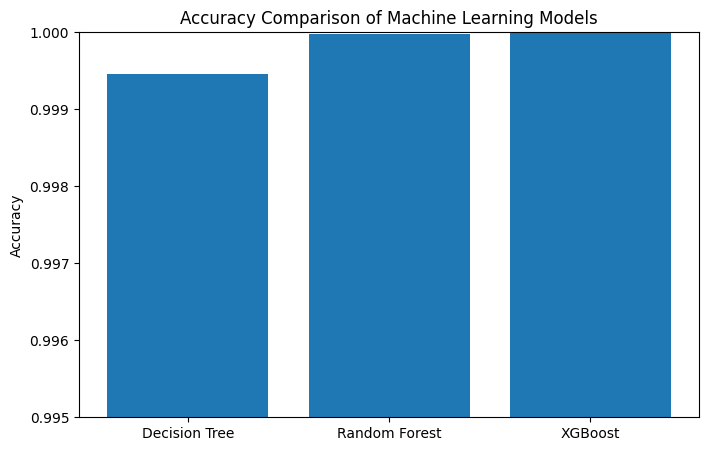

In [34]:
plt.figure(figsize=(8,5))

plt.bar(
    model_results["Model"],
    model_results["Accuracy"]
)

plt.ylabel("Accuracy")

plt.title(
    "Accuracy Comparison of Machine Learning Models"
)

plt.ylim(0.995,1.0)

plt.show()

Precision, Recall and F1 score comparision

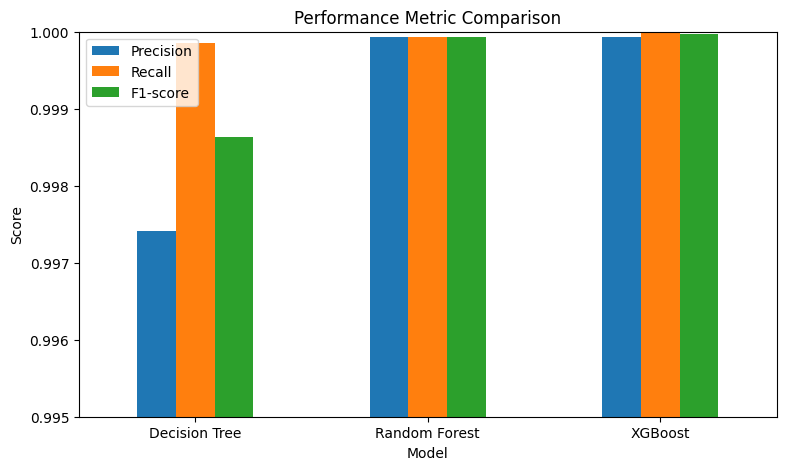

In [35]:
metrics = [
    "Precision",
    "Recall",
    "F1-score"
]


model_results.plot(
    x="Model",
    y=metrics,
    kind="bar",
    figsize=(9,5)
)


plt.ylabel("Score")

plt.title(
    "Performance Metric Comparison"
)

plt.xticks(rotation=0)

plt.ylim(0.995,1.0)

plt.show()

Training time comparision

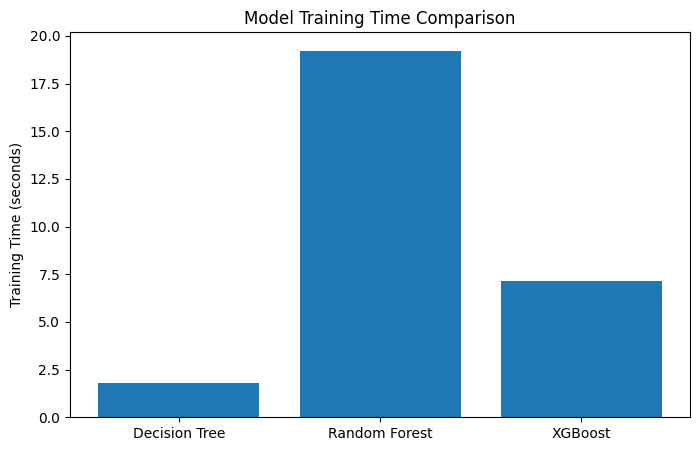

In [36]:
plt.figure(figsize=(8,5))

plt.bar(
    model_results["Model"],
    model_results["Training Time (seconds)"]
)

plt.ylabel(
    "Training Time (seconds)"
)

plt.title(
    "Model Training Time Comparison"
)

plt.show()

Prediction time comparision

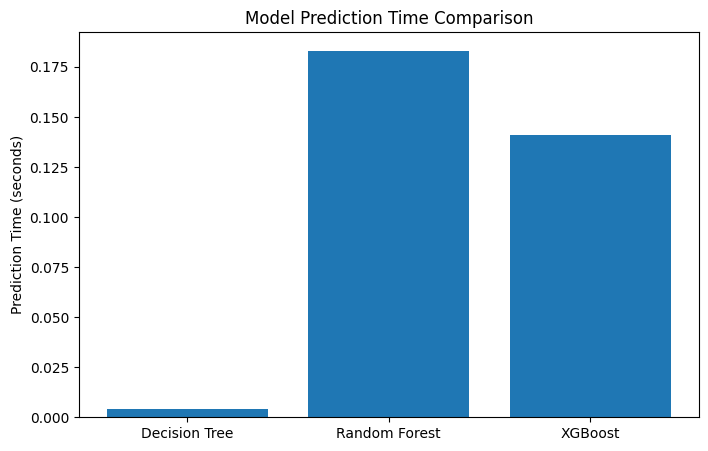

In [37]:
plt.figure(figsize=(8,5))

plt.bar(
    model_results["Model"],
    model_results["Prediction Time (seconds)"]
)

plt.ylabel(
    "Prediction Time (seconds)"
)

plt.title(
    "Model Prediction Time Comparison"
)

plt.show()

Ranking

In [38]:
ranking = model_results.sort_values(
    by="F1-score",
    ascending=False
)


ranking

,Model,Accuracy,Precision,Recall,F1-score,Training Time (seconds),Prediction Time (seconds)
2,XGBoost,0.999986,0.999928,1.000000,0.999964,7.140702,0.140994
1,Random Forest,0.999971,0.999928,0.999928,0.999928,19.230237,0.183151
0,Decision Tree,0.999454,0.997410,0.999856,0.998631,1.804208,0.003913
